In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [33]:
url = "https://raw.githubusercontent.com/eli5-org/eli5/master/notebooks/titanic-train.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [35]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


In [36]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


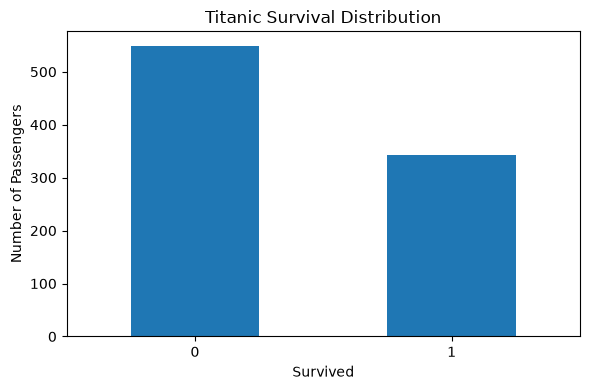

In [37]:
plt.figure(figsize=(6, 4))

df["Survived"].value_counts().plot(kind="bar")

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [38]:
data = df.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"]
).copy()

display(data.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [39]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Target:
Survived


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (712, 7)
Testing set: (179, 7)


In [41]:
rng = np.random.RandomState(42)

leaky_signal = np.where(
    y == 1,
    rng.choice([0, 1], size=len(y), p=[0.10, 0.90]),
    rng.choice([0, 1], size=len(y), p=[0.90, 0.10])
)

X_leaky = X.copy()

X_leaky["post_event_signal"] = leaky_signal

display(X_leaky.head())

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,post_event_signal
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [42]:
X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_leaky,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Leaky training set:", X_train_leaky.shape)
print("Leaky testing set:", X_test_leaky.shape)

Leaky training set: (712, 8)
Leaky testing set: (179, 8)


In [43]:
numeric_features_leaky = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "post_event_signal"
]

categorical_features = [
    "Sex",
    "Embarked"
]

In [44]:
numeric_transformer_leaky = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [45]:
preprocessor_leaky = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_leaky,
            numeric_features_leaky
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [46]:
before_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_leaky),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

before_pipeline.fit(
    X_train_leaky,
    y_train_leaky
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pclass','Sex','Age',...,'Fare','Embarked','post_event_signal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remainin

In [47]:
y_pred_before = before_pipeline.predict(
    X_test_leaky
)

In [48]:
before_accuracy = accuracy_score(
    y_test_leaky,
    y_pred_before
)

before_precision = precision_score(
    y_test_leaky,
    y_pred_before
)

before_recall = recall_score(
    y_test_leaky,
    y_pred_before
)

before_f1 = f1_score(
    y_test_leaky,
    y_pred_before
)

print("========== BEFORE: LEAKAGE ==========")

print(f"Accuracy : {before_accuracy:.4f}")
print(f"Precision: {before_precision:.4f}")
print(f"Recall   : {before_recall:.4f}")
print(f"F1 Score : {before_f1:.4f}")

========== BEFORE: LEAKAGE ==========
Accuracy : 0.8771
Precision: 0.8219
Recall   : 0.8696
F1 Score : 0.8451


## After

In [49]:
X_clean = X.copy()

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

In [51]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [53]:
after_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

after_pipeline.fit(
    X_train_clean,
    y_train_clean
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Pclass','Sex','Age',...,'Parch','Fare','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns th

In [55]:
y_pred_after = after_pipeline.predict(
    X_test_clean
)

In [56]:
after_accuracy = accuracy_score(
    y_test_clean,
    y_pred_after
)

after_precision = precision_score(
    y_test_clean,
    y_pred_after
)

after_recall = recall_score(
    y_test_clean,
    y_pred_after
)

after_f1 = f1_score(
    y_test_clean,
    y_pred_after
)

print("========== AFTER: CORRECT PIPELINE ==========")

print(f"Accuracy : {after_accuracy:.4f}")
print(f"Precision: {after_precision:.4f}")
print(f"Recall   : {after_recall:.4f}")
print(f"F1 Score : {after_f1:.4f}")

========== AFTER: CORRECT PIPELINE ==========
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1 Score : 0.7244


In [57]:
comparison = pd.DataFrame({
    "Model": [
        "Before - Leakage",
        "After - Correct Pipeline"
    ],
    "Accuracy": [
        before_accuracy,
        after_accuracy
    ],
    "Precision": [
        before_precision,
        after_precision
    ],
    "Recall": [
        before_recall,
        after_recall
    ],
    "F1 Score": [
        before_f1,
        after_f1
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Before - Leakage,0.8771,0.8219,0.8696,0.8451
1,After - Correct Pipeline,0.8045,0.7931,0.6667,0.7244


In [58]:
print("Accuracy difference:",
      round(before_accuracy - after_accuracy, 4))

print("F1 Score difference:",
      round(before_f1 - after_f1, 4))

Accuracy difference: 0.0726
F1 Score difference: 0.1207


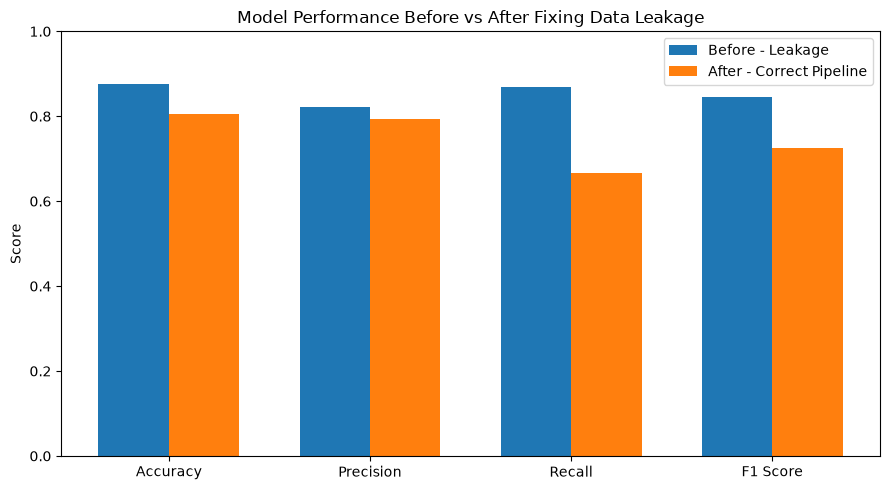

In [59]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

before_values = [
    before_accuracy,
    before_precision,
    before_recall,
    before_f1
]

after_values = [
    after_accuracy,
    after_precision,
    after_recall,
    after_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    before_values,
    width,
    label="Before - Leakage"
)

plt.bar(
    x + width / 2,
    after_values,
    width,
    label="After - Correct Pipeline"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)

plt.title(
    "Model Performance Before vs After Fixing Data Leakage"
)

plt.legend()

plt.tight_layout()
plt.show()

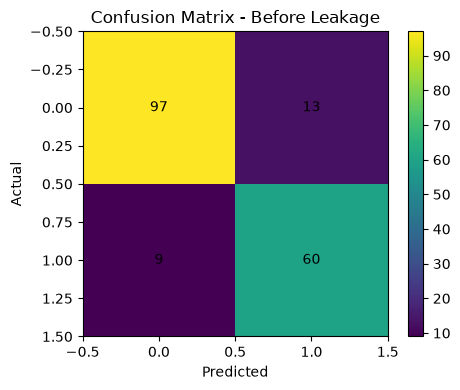

In [60]:
cm_before = confusion_matrix(
    y_test_leaky,
    y_pred_before
)

plt.figure(figsize=(5, 4))

plt.imshow(cm_before)

plt.title("Confusion Matrix - Before Leakage")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

for i in range(cm_before.shape[0]):
    for j in range(cm_before.shape[1]):
        plt.text(
            j,
            i,
            cm_before[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

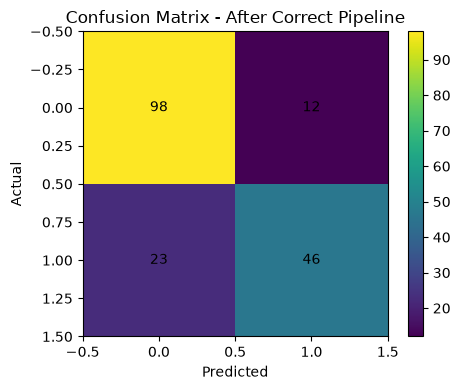

In [61]:
cm_after = confusion_matrix(
    y_test_clean,
    y_pred_after
)

plt.figure(figsize=(5, 4))

plt.imshow(cm_after)

plt.title("Confusion Matrix - After Correct Pipeline")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

for i in range(cm_after.shape[0]):
    for j in range(cm_after.shape[1]):
        plt.text(
            j,
            i,
            cm_after[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [62]:
print("Classification Report - BEFORE")
print(
    classification_report(
        y_test_leaky,
        y_pred_before
    )
)

Classification Report - BEFORE
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       110
           1       0.82      0.87      0.85        69

    accuracy                           0.88       179
   macro avg       0.87      0.88      0.87       179
weighted avg       0.88      0.88      0.88       179



In [63]:
print("Classification Report - AFTER")
print(
    classification_report(
        y_test_clean,
        y_pred_after
    )
)

Classification Report - AFTER
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

